In [2]:
import pandas as pd
from pathlib import Path


In [13]:
Proj_Folder = Path.cwd()

input_file = Proj_Folder / "raw" / "SV.csv"

df = pd.read_csv(input_file, low_memory=False)

# Convert epoch to datetime
df["epoch"] = pd.to_datetime(
    df["epoch"],
    format="mixed",
    utc=True
)

# GEO only
geo = df[df["orbitRegime"] == "GEO"].copy()

print("Rows:", len(geo))
print("Unique satellites:", geo["idOnOrbit"].nunique())
print("Date range:", geo["epoch"].min(), "to", geo["epoch"].max())

Rows: 2279591
Unique satellites: 668
Date range: 2025-07-01 00:00:00+00:00 to 2025-07-31 23:59:59.816014+00:00


In [41]:
#Here we found that satelite 43445 only had two observations so we choose to filter it
#We also found that the different providers had different reporting making data inconsitent
SAT_COL = "idOnOrbit"

geo_new = geo[
    geo[SAT_COL] != 43445
].copy()

geo_filtered = geo_new[
    (geo_new["source"] == "NorthStar") &
    (geo_new["referenceFrame"] == "J2000")
].copy()

print("Rows:", len(geo_filtered))
print("Satellites:", geo_filtered[SAT_COL].nunique())
print(geo_filtered["referenceFrame"].value_counts())

print("Satellites retained:", geo_filtered[SAT_COL].nunique())

all_sats = set(
    geo_new[SAT_COL].unique()
)

northstar_sats = set(
    geo_filtered[SAT_COL].unique()
)

missing_sats = all_sats - northstar_sats


print("Missing satellites:", missing_sats,"and 43445")

Rows: 281227
Satellites: 665
referenceFrame
J2000    281227
Name: count, dtype: int64
Satellites retained: 665
Missing satellites: {44625, 46113} and 43445


In [28]:
thresholds = [15, 30, 60, 120, 240, 360]

for threshold in thresholds:

    # Number of satellites whose BOTH surrounding
    # observations are within threshold minutes
    counts = np.sum(
        max_side_gap <= threshold,
        axis=0
    )

    best_count = counts.max()

    # All timestamps achieving that maximum
    tied = np.where(counts == best_count)[0]

    # Tie-break using lowest median interpolation gap
    medians = np.nanmedian(
        max_side_gap[:, tied],
        axis=0
    )

    best_idx = tied[np.nanargmin(medians)]

    print(
        f"±{threshold:3d} min: "
        f"{best_count}/{len(sat_groups)} satellites "
        f"({100 * best_count / len(sat_groups):.1f}%) "
        f"at {candidate_times[best_idx]}"
    )

± 15 min: 251/667 satellites (37.6%) at 2025-07-17 11:30:00+00:00
± 30 min: 342/667 satellites (51.3%) at 2025-07-25 11:10:00+00:00
± 60 min: 405/667 satellites (60.7%) at 2025-07-25 19:50:00+00:00
±120 min: 440/667 satellites (66.0%) at 2025-07-28 19:00:00+00:00
±240 min: 459/667 satellites (68.8%) at 2025-07-28 18:20:00+00:00
±360 min: 500/667 satellites (75.0%) at 2025-07-25 17:30:00+00:00


In [29]:
#Choosing 60 min window to minimize diminishing returns
MAX_GAP_MIN = 60

# Find the best timestamp for the 60-minute criterion
counts = np.sum(
    max_side_gap <= MAX_GAP_MIN,
    axis=0
)

best_idx = np.argmax(counts)
best_time = candidate_times[best_idx]

# Interpolation gaps at that timestamp
gaps_at_best = pd.Series(
    max_side_gap[:, best_idx],
    index=[sat for sat, _ in sat_groups],
    name="max_gap_min"
)

# Satellites satisfying the interpolation criterion
good_sats = gaps_at_best[
    gaps_at_best <= MAX_GAP_MIN
].index

print("Target epoch:", best_time)
print("Satellites:", len(good_sats))
print(
    f"Coverage: {100*len(good_sats)/len(sat_groups):.1f}%"
)

print("\nGap statistics:")
print(gaps_at_best.loc[good_sats].describe())

Target epoch: 2025-07-25 19:40:00+00:00
Satellites: 405
Coverage: 60.7%

Gap statistics:
count    405.000000
mean      21.784770
std       13.197762
min        0.156390
25%       12.268744
50%       19.978489
75%       29.367704
max       59.507019
Name: max_gap_min, dtype: float64


Rows: 281227
Satellites: 665

Sources:
source
NorthStar    281227
Name: count, dtype: int64

Reference frames:
referenceFrame
J2000    281227
Name: count, dtype: int64

Exact duplicate satellite/epoch rows removed: 1093
Clean validation rows: 280134

Validation observations: 241213
Satellites represented: 664


BIN-SPECIFIC INTERPOLATION ERROR
                 n  median_hermite_km  p95_hermite_km  p99_hermite_km  \
gap_bin                                                                 
0-15 min       154        3890.566122    60028.650693    72079.530003   
15-30 min    87916           0.144565        0.455661        0.929504   
30-60 min    92558           0.598394        2.852359        5.415765   
60-120 min   21147           4.872668       31.731763       63.919494   
120-240 min   6577          32.030515      380.791830      914.945450   
240-360 min   1240          95.270075     1481.089701     2668.668793   
>360 min     31621         476.821275    14492.856643   102384.383225 

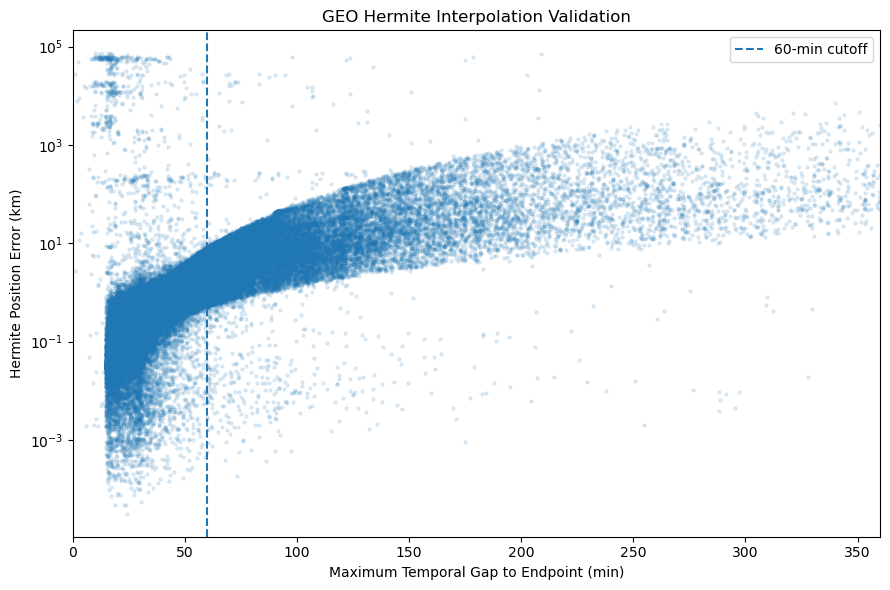

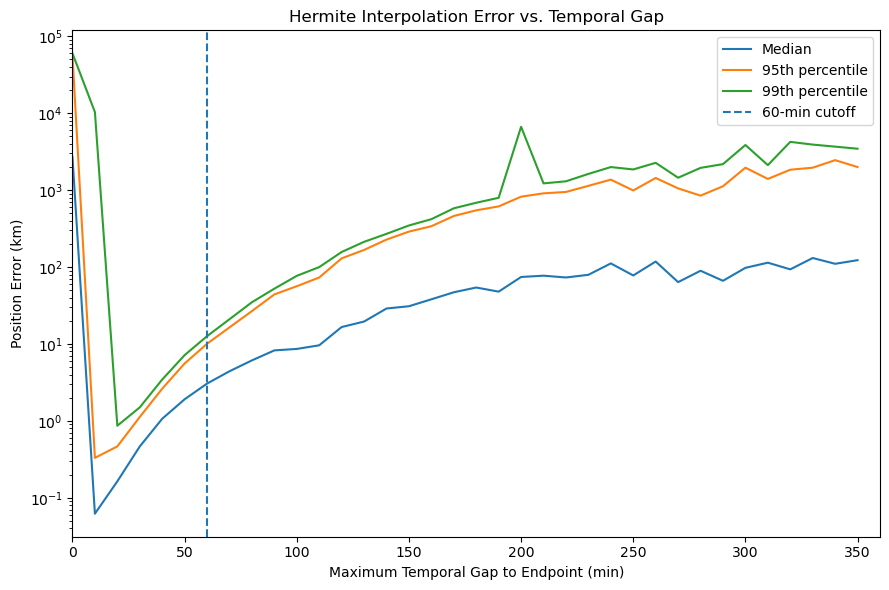

In [44]:
#Now we validate our 60 minute cubic Hermite interpolation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

SAT_COL = "idOnOrbit"

POS_COLS = ["xpos", "ypos", "zpos"]
VEL_COLS = ["xvel", "yvel", "zvel"]

MAX_POINTS_PER_SAT = 500
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)


# ============================================================
# 1. Check the filtered dataset
# ============================================================

print("Rows:", len(geo_filtered))
print("Satellites:", geo_filtered[SAT_COL].nunique())

if "source" in geo_filtered.columns:
    print("\nSources:")
    print(geo_filtered["source"].value_counts(dropna=False))

if "referenceFrame" in geo_filtered.columns:
    print("\nReference frames:")
    print(geo_filtered["referenceFrame"].value_counts(dropna=False))


# ============================================================
# 2. Prepare clean state-vector data
# ============================================================

validation_data = geo_filtered[
    [SAT_COL, "epoch"] + POS_COLS + VEL_COLS
].copy()

# Make sure epoch is datetime
validation_data["epoch"] = pd.to_datetime(
    validation_data["epoch"],
    format="mixed",
    utc=True,
    errors="coerce"
)

# Make sure state-vector values are numeric
for col in POS_COLS + VEL_COLS:
    validation_data[col] = pd.to_numeric(
        validation_data[col],
        errors="coerce"
    )

# Remove missing state vectors
validation_data = validation_data.dropna(
    subset=["epoch"] + POS_COLS + VEL_COLS
)

# Sort
validation_data = validation_data.sort_values(
    [SAT_COL, "epoch"]
)

# ------------------------------------------------------------
# Important:
# Remove exact duplicate epochs for the same satellite.
# ------------------------------------------------------------

n_before = len(validation_data)

validation_data = validation_data.drop_duplicates(
    subset=[SAT_COL, "epoch"],
    keep="first"
)

n_removed = n_before - len(validation_data)

print("\nExact duplicate satellite/epoch rows removed:", n_removed)
print("Clean validation rows:", len(validation_data))


# ============================================================
# 3. Hermite interpolation validation
#
# For three consecutive observations:
#
#       previous ---- hidden ---- next
#
# pretend the middle observation is unknown.
# Use previous + next position/velocity to reconstruct it.
# ============================================================

results = []

for sat, group in validation_data.groupby(SAT_COL):

    group = (
        group
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    # Need previous, hidden, next
    if len(group) < 3:
        continue

    middle_idx = np.arange(
        1,
        len(group) - 1
    )

    # --------------------------------------------------------
    # Balance the validation so extremely dense satellites
    # do not dominate the results
    # --------------------------------------------------------

    if len(middle_idx) > MAX_POINTS_PER_SAT:
        middle_idx = rng.choice(
            middle_idx,
            size=MAX_POINTS_PER_SAT,
            replace=False
        )

    middle_idx = np.sort(middle_idx)

    prev_idx = middle_idx - 1
    next_idx = middle_idx + 1


    # --------------------------------------------------------
    # Times
    # --------------------------------------------------------

    times_ns = (
        group["epoch"]
        .astype("int64")
        .to_numpy()
    )

    t_prev = times_ns[prev_idx]
    t_mid = times_ns[middle_idx]
    t_next = times_ns[next_idx]

    total_seconds = (
        t_next - t_prev
    ) / 1e9

    elapsed_seconds = (
        t_mid - t_prev
    ) / 1e9


    # --------------------------------------------------------
    # Valid interpolation geometry
    # --------------------------------------------------------

    valid = (
        np.isfinite(total_seconds)
        & np.isfinite(elapsed_seconds)
        & (total_seconds > 0)
        & (elapsed_seconds > 0)
        & (elapsed_seconds < total_seconds)
    )

    prev_idx = prev_idx[valid]
    middle_idx = middle_idx[valid]
    next_idx = next_idx[valid]

    total_seconds = total_seconds[valid]
    elapsed_seconds = elapsed_seconds[valid]

    if len(middle_idx) == 0:
        continue


    # --------------------------------------------------------
    # Normalized interpolation coordinate
    # --------------------------------------------------------

    u = (
        elapsed_seconds
        / total_seconds
    )


    # --------------------------------------------------------
    # Position and velocity
    # --------------------------------------------------------

    r_prev = group.loc[
        prev_idx,
        POS_COLS
    ].to_numpy(dtype=float)

    r_true = group.loc[
        middle_idx,
        POS_COLS
    ].to_numpy(dtype=float)

    r_next = group.loc[
        next_idx,
        POS_COLS
    ].to_numpy(dtype=float)


    v_prev = group.loc[
        prev_idx,
        VEL_COLS
    ].to_numpy(dtype=float)

    v_next = group.loc[
        next_idx,
        VEL_COLS
    ].to_numpy(dtype=float)


    # ========================================================
    # Cubic Hermite interpolation
    # ========================================================

    h00 = 2*u**3 - 3*u**2 + 1
    h10 = u**3 - 2*u**2 + u
    h01 = -2*u**3 + 3*u**2
    h11 = u**3 - u**2

    r_hermite = (
        h00[:, None] * r_prev
        + h10[:, None]
          * total_seconds[:, None]
          * v_prev
        + h01[:, None] * r_next
        + h11[:, None]
          * total_seconds[:, None]
          * v_next
    )


    # ========================================================
    # Linear interpolation
    # Used only as a comparison/baseline
    # ========================================================

    r_linear = (
        (1 - u[:, None]) * r_prev
        + u[:, None] * r_next
    )


    # ========================================================
    # 3-D position error
    # ========================================================

    hermite_error = np.linalg.norm(
        r_hermite - r_true,
        axis=1
    )

    linear_error = np.linalg.norm(
        r_linear - r_true,
        axis=1
    )


    # ========================================================
    # Temporal interpolation gaps
    # ========================================================

    before_gap_min = (
        elapsed_seconds / 60
    )

    after_gap_min = (
        total_seconds - elapsed_seconds
    ) / 60

    max_side_gap_min = np.maximum(
        before_gap_min,
        after_gap_min
    )


    # ========================================================
    # Save results
    # ========================================================

    results.append(
        pd.DataFrame({
            SAT_COL: sat,

            "epoch":
                group.loc[
                    middle_idx,
                    "epoch"
                ].to_numpy(),

            "before_gap_min":
                before_gap_min,

            "after_gap_min":
                after_gap_min,

            "max_side_gap_min":
                max_side_gap_min,

            "total_bracket_min":
                total_seconds / 60,

            "hermite_error_km":
                hermite_error,

            "linear_error_km":
                linear_error
        })
    )


# ============================================================
# 4. Combine validation results
# ============================================================

if len(results) == 0:
    raise ValueError(
        "No valid interpolation cases were found."
    )

validation_results = pd.concat(
    results,
    ignore_index=True
)

print(
    "\nValidation observations:",
    len(validation_results)
)

print(
    "Satellites represented:",
    validation_results[SAT_COL].nunique()
)


# ============================================================
# 5. Bin by maximum temporal gap
# ============================================================

bins = [
    0,
    15,
    30,
    60,
    120,
    240,
    360,
    np.inf
]

labels = [
    "0-15 min",
    "15-30 min",
    "30-60 min",
    "60-120 min",
    "120-240 min",
    "240-360 min",
    ">360 min"
]

validation_results["gap_bin"] = pd.cut(
    validation_results["max_side_gap_min"],
    bins=bins,
    labels=labels,
    right=True
)


# ============================================================
# 6. BIN-SPECIFIC summary
#
# This is particularly important for choosing the cutoff.
# ============================================================

bin_summary = (
    validation_results
    .groupby(
        "gap_bin",
        observed=True
    )
    .agg(
        n=(
            "hermite_error_km",
            "count"
        ),

        median_hermite_km=(
            "hermite_error_km",
            "median"
        ),

        p95_hermite_km=(
            "hermite_error_km",
            lambda x: x.quantile(0.95)
        ),

        p99_hermite_km=(
            "hermite_error_km",
            lambda x: x.quantile(0.99)
        ),

        max_hermite_km=(
            "hermite_error_km",
            "max"
        ),

        median_linear_km=(
            "linear_error_km",
            "median"
        ),

        p95_linear_km=(
            "linear_error_km",
            lambda x: x.quantile(0.95)
        )
    )
)

print("\n")
print("=" * 70)
print("BIN-SPECIFIC INTERPOLATION ERROR")
print("=" * 70)
print(bin_summary)


# ============================================================
# 7. CUMULATIVE threshold statistics
# ============================================================

print("\n")
print("=" * 70)
print("CUMULATIVE INTERPOLATION ERROR")
print("=" * 70)

for threshold in [
    15,
    30,
    60,
    120,
    240,
    360
]:

    subset = validation_results[
        validation_results[
            "max_side_gap_min"
        ] <= threshold
    ]

    if len(subset) == 0:
        continue

    print(
        f"\n<= {threshold} min"
    )

    print(
        f"N: {len(subset)}"
    )

    print(
        "Hermite median:",
        f"{subset['hermite_error_km'].median():.3f} km"
    )

    print(
        "Hermite 95%:",
        f"{subset['hermite_error_km'].quantile(0.95):.3f} km"
    )

    print(
        "Hermite 99%:",
        f"{subset['hermite_error_km'].quantile(0.99):.3f} km"
    )

    print(
        "Linear median:",
        f"{subset['linear_error_km'].median():.3f} km"
    )

    print(
        "Linear 95%:",
        f"{subset['linear_error_km'].quantile(0.95):.3f} km"
    )


# ============================================================
# 8. Examine 60-minute validation specifically
# ============================================================

val60 = validation_results[
    validation_results[
        "max_side_gap_min"
    ] <= 60
].copy()

print("\n")
print("=" * 70)
print("60-MINUTE VALIDATION")
print("=" * 70)

print(
    "Validation cases:",
    len(val60)
)


# ------------------------------------------------------------
# Largest errors
# ------------------------------------------------------------

print(
    "\nLargest interpolation errors:"
)

print(
    val60[
        [
            SAT_COL,
            "epoch",
            "before_gap_min",
            "after_gap_min",
            "total_bracket_min",
            "hermite_error_km",
            "linear_error_km"
        ]
    ]
    .sort_values(
        "hermite_error_km",
        ascending=False
    )
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 9. Per-satellite validation quality
# ============================================================

sat_validation = (
    val60
    .groupby(SAT_COL)
    .agg(

        n=(
            "hermite_error_km",
            "count"
        ),

        median_error_km=(
            "hermite_error_km",
            "median"
        ),

        p95_error_km=(
            "hermite_error_km",
            lambda x: x.quantile(0.95)
        ),

        max_error_km=(
            "hermite_error_km",
            "max"
        ),

        errors_gt_1km=(
            "hermite_error_km",
            lambda x: (x > 1).sum()
        ),

        errors_gt_10km=(
            "hermite_error_km",
            lambda x: (x > 10).sum()
        ),

        errors_gt_50km=(
            "hermite_error_km",
            lambda x: (x > 50).sum()
        )
    )
)

sat_validation["pct_gt_1km"] = (
    100
    * sat_validation["errors_gt_1km"]
    / sat_validation["n"]
)

sat_validation["pct_gt_10km"] = (
    100
    * sat_validation["errors_gt_10km"]
    / sat_validation["n"]
)


print("\n")
print("=" * 70)
print("WORST SATELLITES AT <= 60 MIN")
print("=" * 70)

print(
    sat_validation
    .sort_values(
        "pct_gt_10km",
        ascending=False
    )
    .head(30)
)


# ============================================================
# 10. Scatter plot
# ============================================================

plot_data = validation_results[
    validation_results[
        "max_side_gap_min"
    ] <= 360
].copy()

plt.figure(figsize=(9, 6))

plt.scatter(
    plot_data["max_side_gap_min"],
    plot_data["hermite_error_km"],
    s=5,
    alpha=0.12
)

plt.axvline(
    60,
    linestyle="--",
    label="60-min cutoff"
)

plt.xlabel(
    "Maximum Temporal Gap to Endpoint (min)"
)

plt.ylabel(
    "Hermite Position Error (km)"
)

plt.title(
    "GEO Hermite Interpolation Validation"
)

plt.yscale("log")
plt.xlim(0, 360)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. Quantile error curve
#
# Much easier to interpret than the raw scatter.
# ============================================================

curve_data = validation_results[
    validation_results[
        "max_side_gap_min"
    ] <= 360
].copy()

curve_data["gap_10min"] = (
    curve_data[
        "max_side_gap_min"
    ] // 10
) * 10

quantile_curve = (
    curve_data
    .groupby("gap_10min")
    ["hermite_error_km"]
    .agg(
        median="median",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
        n="count"
    )
    .reset_index()
)

plt.figure(figsize=(9, 6))

plt.plot(
    quantile_curve["gap_10min"],
    quantile_curve["median"],
    label="Median"
)

plt.plot(
    quantile_curve["gap_10min"],
    quantile_curve["p95"],
    label="95th percentile"
)

plt.plot(
    quantile_curve["gap_10min"],
    quantile_curve["p99"],
    label="99th percentile"
)

plt.axvline(
    60,
    linestyle="--",
    label="60-min cutoff"
)

plt.xlabel(
    "Maximum Temporal Gap to Endpoint (min)"
)

plt.ylabel(
    "Position Error (km)"
)

plt.title(
    "Hermite Interpolation Error vs. Temporal Gap"
)

plt.yscale("log")

plt.xlim(0, 360)

plt.legend()
plt.tight_layout()
plt.show()

Rows: 280134
Satellites: 665
Validation cases: 241213
Satellites represented: 664
99th-percentile Hermite error for 30-60 min: 5.416 km
Trusted validation cases: 179214

Empirical physical limits
-----------------------------------
Chord speed: 3.0246 to 3.0853 km/s
Endpoint speed: 3.0350 to 3.0918 km/s
Max velocity-vector change: 1.3599 km/s
Max radial change: 103.83 km

<= 60 min BEFORE physical screening
N: 180628
Median error: 0.29781198343780824
95th percentile: 2.100541163494694
99th percentile: 4.850701235285424

<= 60 min AFTER physical screening
N: 176411
Median error: 0.29353832187463647
95th percentile: 1.871093082110948
99th percentile: 3.4223449133996455
Maximum error: 72585.33272746447
Candidate times: 4463
Satellites: 665
Maximum usable satellites: 344
Number of tied candidate times: 1

BEST SNAPSHOT
Target epoch: 2025-07-28 18:30:00+00:00
Usable satellites: 344 / 665
Coverage: 51.7%
Median max gap: 22.93 min


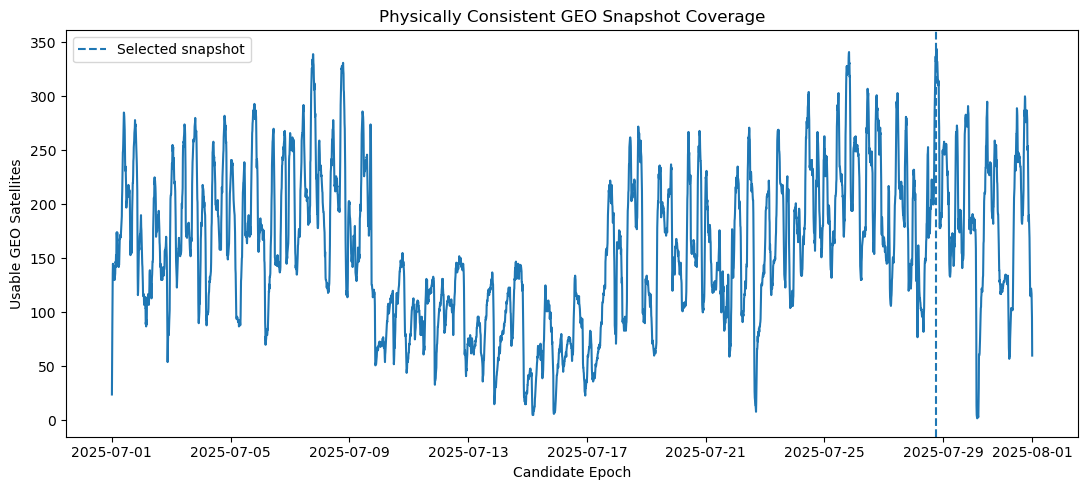

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

SAT_COL = "idOnOrbit"

POS_COLS = ["xpos", "ypos", "zpos"]
VEL_COLS = ["xvel", "yvel", "zvel"]

MAX_POINTS_PER_SAT = 500
RANDOM_STATE = 42

# Maximum distance from target time to either endpoint
MAX_GAP_MIN = 60

# Search possible snapshot times every 10 minutes
TIME_STEP = "10min"

rng = np.random.default_rng(RANDOM_STATE)


# ============================================================
# 1. PREPARE DATA
# ============================================================

cols = (
    [SAT_COL, "epoch"]
    + POS_COLS
    + VEL_COLS
)

# Keep useful metadata if available
optional_cols = [
    "commonName",
    "source",
    "referenceFrame"
]

for col in optional_cols:
    if col in geo_filtered.columns:
        cols.append(col)


data = geo_filtered[cols].copy()

data["epoch"] = pd.to_datetime(
    data["epoch"],
    format="mixed",
    utc=True,
    errors="coerce"
)

for col in POS_COLS + VEL_COLS:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data = data.dropna(
    subset=["epoch"] + POS_COLS + VEL_COLS
)

data = (
    data
    .sort_values([SAT_COL, "epoch"])
    .drop_duplicates(
        subset=[SAT_COL, "epoch"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("Rows:", len(data))
print("Satellites:", data[SAT_COL].nunique())

# ============================================================
# 2. LEAVE-ONE-OUT HERMITE VALIDATION
# ============================================================

results = []

for sat, group in data.groupby(SAT_COL):

    group = (
        group
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    if len(group) < 3:
        continue


    # --------------------------------------------------------
    # Select middle points to hide
    # --------------------------------------------------------

    middle_idx = np.arange(
        1,
        len(group) - 1
    )

    if len(middle_idx) > MAX_POINTS_PER_SAT:
        middle_idx = rng.choice(
            middle_idx,
            size=MAX_POINTS_PER_SAT,
            replace=False
        )

    middle_idx = np.sort(middle_idx)

    prev_idx = middle_idx - 1
    next_idx = middle_idx + 1


    # --------------------------------------------------------
    # Time arrays
    # --------------------------------------------------------

    times_ns = (
        group["epoch"]
        .astype("int64")
        .to_numpy()
    )

    t_prev = times_ns[prev_idx]
    t_mid  = times_ns[middle_idx]
    t_next = times_ns[next_idx]

    total_seconds = (
        t_next - t_prev
    ) / 1e9

    elapsed_seconds = (
        t_mid - t_prev
    ) / 1e9


    valid = (
        np.isfinite(total_seconds)
        & (total_seconds > 0)
        & (elapsed_seconds > 0)
        & (elapsed_seconds < total_seconds)
    )

    prev_idx = prev_idx[valid]
    middle_idx = middle_idx[valid]
    next_idx = next_idx[valid]

    total_seconds = total_seconds[valid]
    elapsed_seconds = elapsed_seconds[valid]

    if len(middle_idx) == 0:
        continue


    # --------------------------------------------------------
    # State vectors
    # --------------------------------------------------------

    r_prev = group.loc[
        prev_idx,
        POS_COLS
    ].to_numpy(dtype=float)

    r_true = group.loc[
        middle_idx,
        POS_COLS
    ].to_numpy(dtype=float)

    r_next = group.loc[
        next_idx,
        POS_COLS
    ].to_numpy(dtype=float)


    v_prev = group.loc[
        prev_idx,
        VEL_COLS
    ].to_numpy(dtype=float)

    v_next = group.loc[
        next_idx,
        VEL_COLS
    ].to_numpy(dtype=float)


    # --------------------------------------------------------
    # Hermite interpolation
    # --------------------------------------------------------

    u = elapsed_seconds / total_seconds

    h00 = 2*u**3 - 3*u**2 + 1
    h10 = u**3 - 2*u**2 + u
    h01 = -2*u**3 + 3*u**2
    h11 = u**3 - u**2

    r_hermite = (
        h00[:, None] * r_prev
        + h10[:, None]
          * total_seconds[:, None]
          * v_prev
        + h01[:, None] * r_next
        + h11[:, None]
          * total_seconds[:, None]
          * v_next
    )


    # --------------------------------------------------------
    # Actual interpolation error
    # --------------------------------------------------------

    hermite_error = np.linalg.norm(
        r_hermite - r_true,
        axis=1
    )


    # --------------------------------------------------------
    # Temporal gap
    # --------------------------------------------------------

    before_gap_min = (
        elapsed_seconds / 60
    )

    after_gap_min = (
        total_seconds - elapsed_seconds
    ) / 60

    max_side_gap_min = np.maximum(
        before_gap_min,
        after_gap_min
    )


    # ========================================================
    # PHYSICAL CONSISTENCY METRICS
    # ========================================================

    # Straight-line displacement between endpoints
    chord_distance_km = np.linalg.norm(
        r_next - r_prev,
        axis=1
    )

    # Average apparent speed across interpolation bracket
    endpoint_chord_speed_kms = (
        chord_distance_km /
        total_seconds
    )

    # Speed at each endpoint
    speed_prev_kms = np.linalg.norm(
        v_prev,
        axis=1
    )

    speed_next_kms = np.linalg.norm(
        v_next,
        axis=1
    )

    # Difference between endpoint velocity vectors
    endpoint_dv_kms = np.linalg.norm(
        v_next - v_prev,
        axis=1
    )

    # Radius at each endpoint
    radius_prev_km = np.linalg.norm(
        r_prev,
        axis=1
    )

    radius_next_km = np.linalg.norm(
        r_next,
        axis=1
    )

    radius_change_km = np.abs(
        radius_next_km -
        radius_prev_km
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    results.append(
        pd.DataFrame({
            SAT_COL: sat,

            "epoch":
                group.loc[
                    middle_idx,
                    "epoch"
                ].to_numpy(),

            "before_gap_min":
                before_gap_min,

            "after_gap_min":
                after_gap_min,

            "max_side_gap_min":
                max_side_gap_min,

            "total_bracket_min":
                total_seconds / 60,

            "hermite_error_km":
                hermite_error,

            "endpoint_chord_speed_kms":
                endpoint_chord_speed_kms,

            "speed_prev_kms":
                speed_prev_kms,

            "speed_next_kms":
                speed_next_kms,

            "endpoint_dv_kms":
                endpoint_dv_kms,

            "radius_change_km":
                radius_change_km
        })
    )


validation_results = pd.concat(
    results,
    ignore_index=True
)

print(
    "Validation cases:",
    len(validation_results)
)

print(
    "Satellites represented:",
    validation_results[SAT_COL].nunique()
)
# ============================================================
# 3. DEFINE EMPIRICALLY TRUSTED CASES
# ============================================================

reference_bin = validation_results[
    (validation_results["max_side_gap_min"] > 30)
    &
    (validation_results["max_side_gap_min"] <= 60)
].copy()

# Use the 99th percentile error in the 30-60 minute bin
# as the definition of a successful reconstruction
GOOD_ERROR_KM = (
    reference_bin["hermite_error_km"]
    .quantile(0.99)
)

print(
    "99th-percentile Hermite error "
    "for 30-60 min:",
    f"{GOOD_ERROR_KM:.3f} km"
)
trusted = validation_results[
    (validation_results["max_side_gap_min"] <= MAX_GAP_MIN)
    &
    (validation_results["hermite_error_km"] <= GOOD_ERROR_KM)
].copy()

print(
    "Trusted validation cases:",
    len(trusted)
)
# ============================================================
# EMPIRICAL PHYSICAL LIMITS
#
# Use 0.5th / 99.5th percentiles so a few extreme
# observations do not dictate the thresholds.
# ============================================================

CHORD_SPEED_LOW = (
    trusted["endpoint_chord_speed_kms"]
    .quantile(0.005)
)

CHORD_SPEED_HIGH = (
    trusted["endpoint_chord_speed_kms"]
    .quantile(0.995)
)

ENDPOINT_SPEED_LOW = min(
    trusted["speed_prev_kms"].quantile(0.005),
    trusted["speed_next_kms"].quantile(0.005)
)

ENDPOINT_SPEED_HIGH = max(
    trusted["speed_prev_kms"].quantile(0.995),
    trusted["speed_next_kms"].quantile(0.995)
)

DV_HIGH = (
    trusted["endpoint_dv_kms"]
    .quantile(0.995)
)

RADIUS_CHANGE_HIGH = (
    trusted["radius_change_km"]
    .quantile(0.995)
)


print("\nEmpirical physical limits")
print("-----------------------------------")

print(
    "Chord speed:",
    f"{CHORD_SPEED_LOW:.4f}",
    "to",
    f"{CHORD_SPEED_HIGH:.4f}",
    "km/s"
)

print(
    "Endpoint speed:",
    f"{ENDPOINT_SPEED_LOW:.4f}",
    "to",
    f"{ENDPOINT_SPEED_HIGH:.4f}",
    "km/s"
)

print(
    "Max velocity-vector change:",
    f"{DV_HIGH:.4f} km/s"
)

print(
    "Max radial change:",
    f"{RADIUS_CHANGE_HIGH:.2f} km"
)
validation_results["physical_ok"] = (
    validation_results["endpoint_chord_speed_kms"].between(
        CHORD_SPEED_LOW,
        CHORD_SPEED_HIGH
    )
    &
    validation_results["speed_prev_kms"].between(
        ENDPOINT_SPEED_LOW,
        ENDPOINT_SPEED_HIGH
    )
    &
    validation_results["speed_next_kms"].between(
        ENDPOINT_SPEED_LOW,
        ENDPOINT_SPEED_HIGH
    )
    &
    (
        validation_results["endpoint_dv_kms"]
        <= DV_HIGH
    )
    &
    (
        validation_results["radius_change_km"]
        <= RADIUS_CHANGE_HIGH
    )
)


val60 = validation_results[
    validation_results["max_side_gap_min"]
    <= MAX_GAP_MIN
].copy()


print("\n<= 60 min BEFORE physical screening")

print(
    "N:",
    len(val60)
)

print(
    "Median error:",
    val60["hermite_error_km"].median()
)

print(
    "95th percentile:",
    val60["hermite_error_km"].quantile(0.95)
)

print(
    "99th percentile:",
    val60["hermite_error_km"].quantile(0.99)
)


val60_clean = val60[
    val60["physical_ok"]
]


print("\n<= 60 min AFTER physical screening")

print(
    "N:",
    len(val60_clean)
)

print(
    "Median error:",
    val60_clean["hermite_error_km"].median()
)

print(
    "95th percentile:",
    val60_clean["hermite_error_km"].quantile(0.95)
)

print(
    "99th percentile:",
    val60_clean["hermite_error_km"].quantile(0.99)
)

print(
    "Maximum error:",
    val60_clean["hermite_error_km"].max()
)
# ============================================================
# 5. CANDIDATE SNAPSHOT TIMES
# ============================================================

candidate_times = pd.date_range(
    start=data["epoch"].min().ceil(TIME_STEP),
    end=data["epoch"].max().floor(TIME_STEP),
    freq=TIME_STEP
)

candidate_ns = candidate_times.asi8

sat_groups = list(
    data.groupby(SAT_COL)
)

n_sats = len(sat_groups)
n_times = len(candidate_times)

print(
    "Candidate times:",
    n_times
)

print(
    "Satellites:",
    n_sats
)
# Each row = satellite
# Each column = possible t0

usable_matrix = np.zeros(
    (n_sats, n_times),
    dtype=bool
)

gap_matrix = np.full(
    (n_sats, n_times),
    np.nan
)

chord_speed_matrix = np.full(
    (n_sats, n_times),
    np.nan
)
for i, (sat, group) in enumerate(sat_groups):

    group = (
        group
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    times_ns = (
        group["epoch"]
        .astype("int64")
        .to_numpy()
    )

    positions = group[
        POS_COLS
    ].to_numpy(dtype=float)

    velocities = group[
        VEL_COLS
    ].to_numpy(dtype=float)


    # --------------------------------------------------------
    # Find the observation immediately AFTER each candidate.
    # Observation immediately before = idx - 1.
    # --------------------------------------------------------

    idx = np.searchsorted(
        times_ns,
        candidate_ns,
        side="right"
    )

    valid = (
        (idx > 0)
        &
        (idx < len(times_ns))
    )

    candidate_indices = np.where(valid)[0]

    if len(candidate_indices) == 0:
        continue

    j = idx[valid]

    before_idx = j - 1
    after_idx = j


    t_before = times_ns[before_idx]
    t_after = times_ns[after_idx]

    target = candidate_ns[valid]


    # --------------------------------------------------------
    # Temporal gaps
    # --------------------------------------------------------

    before_gap_min = (
        target - t_before
    ) / 60e9

    after_gap_min = (
        t_after - target
    ) / 60e9

    max_gap = np.maximum(
        before_gap_min,
        after_gap_min
    )


    # --------------------------------------------------------
    # Endpoint states
    # --------------------------------------------------------

    r_before = positions[before_idx]
    r_after = positions[after_idx]

    v_before = velocities[before_idx]
    v_after = velocities[after_idx]

    total_seconds = (
        t_after - t_before
    ) / 1e9


    # --------------------------------------------------------
    # Physical consistency
    # --------------------------------------------------------

    chord_distance = np.linalg.norm(
        r_after - r_before,
        axis=1
    )

    chord_speed = (
        chord_distance /
        total_seconds
    )

    speed_before = np.linalg.norm(
        v_before,
        axis=1
    )

    speed_after = np.linalg.norm(
        v_after,
        axis=1
    )

    delta_v = np.linalg.norm(
        v_after - v_before,
        axis=1
    )

    radius_before = np.linalg.norm(
        r_before,
        axis=1
    )

    radius_after = np.linalg.norm(
        r_after,
        axis=1
    )

    radius_change = np.abs(
        radius_after -
        radius_before
    )


    # --------------------------------------------------------
    # Criteria
    # --------------------------------------------------------

    time_ok = (
        max_gap <= MAX_GAP_MIN
    )

    chord_ok = (
        (chord_speed >= CHORD_SPEED_LOW)
        &
        (chord_speed <= CHORD_SPEED_HIGH)
    )

    endpoint_speed_ok = (
        (speed_before >= ENDPOINT_SPEED_LOW)
        &
        (speed_before <= ENDPOINT_SPEED_HIGH)
        &
        (speed_after >= ENDPOINT_SPEED_LOW)
        &
        (speed_after <= ENDPOINT_SPEED_HIGH)
    )

    dv_ok = (
        delta_v <= DV_HIGH
    )

    radius_ok = (
        radius_change <= RADIUS_CHANGE_HIGH
    )


    physically_consistent = (
        chord_ok
        &
        endpoint_speed_ok
        &
        dv_ok
        &
        radius_ok
    )


    usable = (
        time_ok
        &
        physically_consistent
    )


    usable_matrix[
        i,
        candidate_indices
    ] = usable

    gap_matrix[
        i,
        candidate_indices
    ] = max_gap

    chord_speed_matrix[
        i,
        candidate_indices
    ] = chord_speed
# ============================================================
# 6. CHOOSE BEST t0
# ============================================================

counts = usable_matrix.sum(axis=0)

max_count = counts.max()

tied_indices = np.where(
    counts == max_count
)[0]

print(
    "Maximum usable satellites:",
    max_count
)

print(
    "Number of tied candidate times:",
    len(tied_indices)
)
median_gaps = []

for idx in tied_indices:

    usable_here = usable_matrix[:, idx]

    gaps_here = gap_matrix[
        usable_here,
        idx
    ]

    median_gaps.append(
        np.nanmedian(gaps_here)
    )

best_idx = tied_indices[
    np.argmin(median_gaps)
]

best_time = candidate_times[
    best_idx
]

best_count = counts[
    best_idx
]


print("\nBEST SNAPSHOT")

print(
    "Target epoch:",
    best_time
)

print(
    "Usable satellites:",
    best_count,
    "/",
    n_sats
)

print(
    "Coverage:",
    f"{100 * best_count/n_sats:.1f}%"
)

print(
    "Median max gap:",
    f"{np.nanmedian(gap_matrix[usable_matrix[:, best_idx], best_idx]):.2f} min"
)
plt.figure(figsize=(11, 5))

plt.plot(
    candidate_times,
    counts
)

plt.axvline(
    best_time,
    linestyle="--",
    label="Selected snapshot"
)

plt.xlabel("Candidate Epoch")
plt.ylabel("Usable GEO Satellites")

plt.title(
    "Physically Consistent GEO Snapshot Coverage"
)

plt.legend()
plt.tight_layout()
plt.show()



FINAL SNAPSHOT
--------------------------------
Epoch: 2025-07-28 18:30:00+00:00
Satellites: 344

Interpolation gaps:
count    344.000000
mean      25.167622
std       11.802549
min        7.926902
25%       15.060692
50%       22.927919
75%       30.002823
max       59.961131
Name: max_gap_min, dtype: float64

Chord speeds:
count    344.000000
mean       3.068487
std        0.008188
min        3.028181
25%        3.067995
50%        3.071838
75%        3.073018
max        3.081444
Name: endpoint_chord_speed_kms, dtype: float64
count      344.000000
mean     42232.859958
std        171.395591
min      41900.984788
25%      42164.201237
50%      42169.686139
75%      42182.135668
max      43182.548559
Name: radius_km, dtype: float64


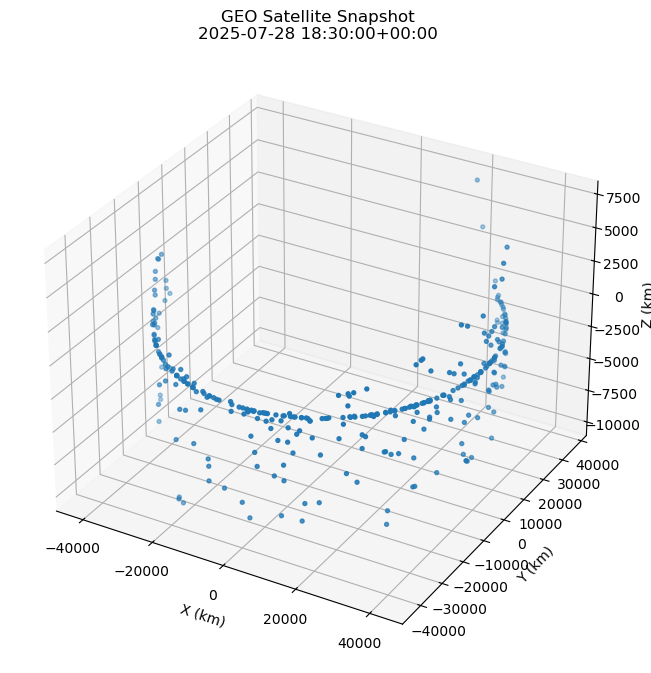

Angular coverage diagnostics
--------------------------------
Satellites: 344
Mean angular spacing: 1.05 deg
Median angular spacing: 0.44 deg
95th-percentile gap: 2.19 deg
Largest empty angular gap: 126.59 deg


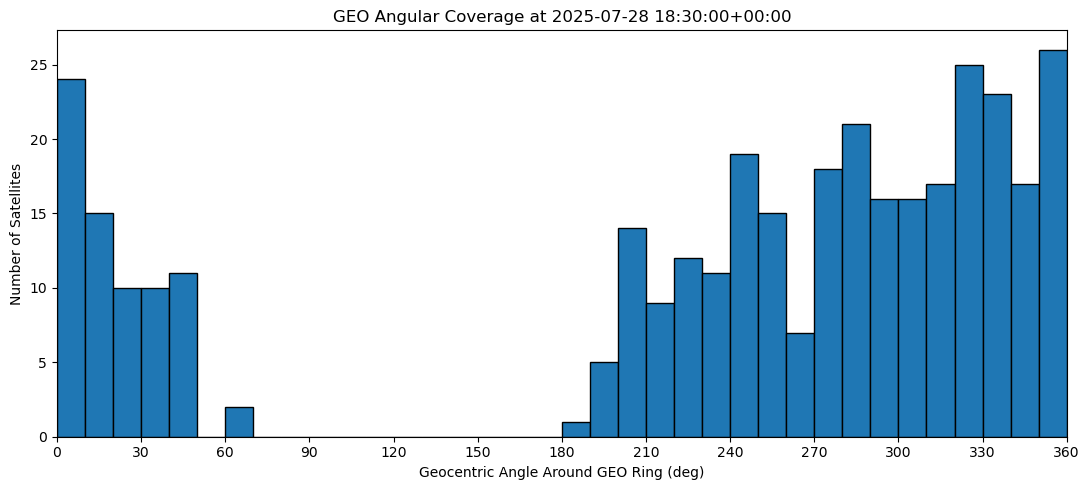

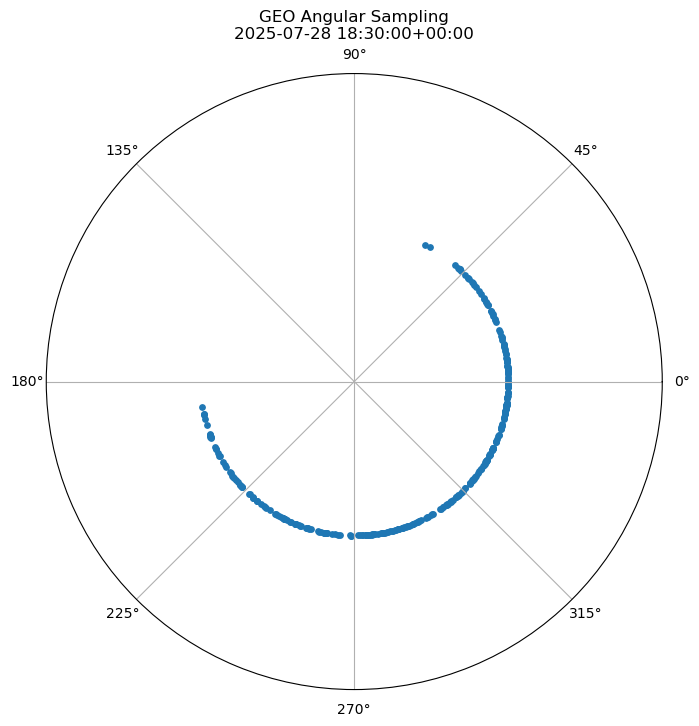

Largest angular gap: 126.59°
From: 62.78°
To: 189.37°


In [49]:
# ============================================================
# 8. FINAL SNAPSHOT AT best_time
# ============================================================

snapshot_rows = []

best_ns = best_time.value


for i, (sat, group) in enumerate(sat_groups):

    # Skip satellites that failed our criteria
    if not usable_matrix[i, best_idx]:
        continue

    group = (
        group
        .sort_values("epoch")
        .reset_index(drop=True)
    )

    times_ns = (
        group["epoch"]
        .astype("int64")
        .to_numpy()
    )

    idx = np.searchsorted(
        times_ns,
        best_ns,
        side="right"
    )

    if idx == 0 or idx >= len(group):
        continue


    before_idx = idx - 1
    after_idx = idx


    t_before = group.loc[
        before_idx,
        "epoch"
    ]

    t_after = group.loc[
        after_idx,
        "epoch"
    ]


    r_before = group.loc[
        before_idx,
        POS_COLS
    ].to_numpy(dtype=float)

    r_after = group.loc[
        after_idx,
        POS_COLS
    ].to_numpy(dtype=float)


    v_before = group.loc[
        before_idx,
        VEL_COLS
    ].to_numpy(dtype=float)

    v_after = group.loc[
        after_idx,
        VEL_COLS
    ].to_numpy(dtype=float)


    total_seconds = (
        t_after - t_before
    ).total_seconds()

    elapsed_seconds = (
        best_time - t_before
    ).total_seconds()


    u = (
        elapsed_seconds /
        total_seconds
    )


    # --------------------------------------------------------
    # Hermite basis
    # --------------------------------------------------------

    h00 = 2*u**3 - 3*u**2 + 1
    h10 = u**3 - 2*u**2 + u
    h01 = -2*u**3 + 3*u**2
    h11 = u**3 - u**2


    r_interp = (
        h00 * r_before
        + h10
          * total_seconds
          * v_before
        + h01 * r_after
        + h11
          * total_seconds
          * v_after
    )


    # --------------------------------------------------------
    # Quality information
    # --------------------------------------------------------

    before_gap_min = (
        best_time - t_before
    ).total_seconds() / 60

    after_gap_min = (
        t_after - best_time
    ).total_seconds() / 60

    chord_speed = (
        np.linalg.norm(
            r_after - r_before
        )
        /
        total_seconds
    )


    row = {
        SAT_COL: sat,

        "target_epoch":
            best_time,

        "xpos":
            r_interp[0],

        "ypos":
            r_interp[1],

        "zpos":
            r_interp[2],

        "before_epoch":
            t_before,

        "after_epoch":
            t_after,

        "before_gap_min":
            before_gap_min,

        "after_gap_min":
            after_gap_min,

        "max_gap_min":
            max(
                before_gap_min,
                after_gap_min
            ),

        "endpoint_chord_speed_kms":
            chord_speed
    }


    # Add metadata
    for col in [
        "commonName",
        "source",
        "referenceFrame"
    ]:

        if col in group.columns:

            value = group.loc[
                before_idx,
                col
            ]

            row[col] = value


    snapshot_rows.append(row)


snapshot = pd.DataFrame(
    snapshot_rows
)


print("\nFINAL SNAPSHOT")
print("--------------------------------")

print(
    "Epoch:",
    best_time
)

print(
    "Satellites:",
    len(snapshot)
)

print("\nInterpolation gaps:")
print(
    snapshot["max_gap_min"]
    .describe()
)

print("\nChord speeds:")
print(
    snapshot[
        "endpoint_chord_speed_kms"
    ]
    .describe()
)
snapshot["radius_km"] = np.sqrt(
    snapshot["xpos"]**2
    +
    snapshot["ypos"]**2
    +
    snapshot["zpos"]**2
)

print(
    snapshot["radius_km"]
    .describe()
)
fig = plt.figure(
    figsize=(8, 8)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    snapshot["xpos"],
    snapshot["ypos"],
    snapshot["zpos"],
    s=8
)

ax.set_xlabel("X (km)")
ax.set_ylabel("Y (km)")
ax.set_zlabel("Z (km)")

ax.set_title(
    f"GEO Satellite Snapshot\n{best_time}"
)

plt.show()

# ============================================================
# GEO ANGULAR COVERAGE CHECK
# ============================================================

snapshot["angle_rad"] = np.arctan2(
    snapshot["ypos"],
    snapshot["xpos"]
)

snapshot["angle_deg"] = np.degrees(
    snapshot["angle_rad"]
)

# Convert from [-180, 180] to [0, 360)
snapshot["angle_deg_360"] = (
    snapshot["angle_deg"] + 360
) % 360


# ============================================================
# Sort angles around the GEO ring
# ============================================================

angles = np.sort(
    snapshot["angle_deg_360"].to_numpy()
)

# Consecutive angular gaps
angular_gaps = np.diff(angles)

# Include wrap-around:
# last satellite -> first satellite
wrap_gap = (
    angles[0] + 360 - angles[-1]
)

angular_gaps = np.append(
    angular_gaps,
    wrap_gap
)


print("Angular coverage diagnostics")
print("--------------------------------")

print(
    "Satellites:",
    len(snapshot)
)

print(
    "Mean angular spacing:",
    f"{angular_gaps.mean():.2f} deg"
)

print(
    "Median angular spacing:",
    f"{np.median(angular_gaps):.2f} deg"
)

print(
    "95th-percentile gap:",
    f"{np.quantile(angular_gaps, 0.95):.2f} deg"
)

print(
    "Largest empty angular gap:",
    f"{angular_gaps.max():.2f} deg"
)

plt.figure(figsize=(11, 5))

plt.hist(
    snapshot["angle_deg_360"],
    bins=np.arange(0, 361, 10),
    edgecolor="black"
)

plt.xlabel("Geocentric Angle Around GEO Ring (deg)")
plt.ylabel("Number of Satellites")

plt.title(
    f"GEO Angular Coverage at {best_time}"
)

plt.xticks(
    np.arange(0, 361, 30)
)

plt.xlim(0, 360)

plt.tight_layout()
plt.show()

fig = plt.figure(
    figsize=(8, 8)
)

ax = fig.add_subplot(
    111,
    projection="polar"
)

theta = np.radians(
    snapshot["angle_deg_360"]
)

ax.scatter(
    theta,
    np.ones(len(snapshot)),
    s=15
)

ax.set_yticks([])

ax.set_title(
    f"GEO Angular Sampling\n{best_time}"
)

plt.show()

gap_idx = np.argmax(angular_gaps)

if gap_idx < len(angles) - 1:

    gap_start = angles[gap_idx]
    gap_end = angles[gap_idx + 1]

else:

    gap_start = angles[-1]
    gap_end = angles[0] + 360


print(
    "Largest angular gap:",
    f"{angular_gaps[gap_idx]:.2f}°"
)

print(
    "From:",
    f"{gap_start:.2f}°"
)

print(
    "To:",
    f"{gap_end % 360:.2f}°"
)